<a href="https://colab.research.google.com/github/NABI-SNU/book/blob/main/tutorials/Session_2_BayesianInference/instructor/Tutorial1.ipynb" target="_blank"><img alt="Open In Colab" src="https://colab.research.google.com/assets/colab-badge.svg"/></a>   <a href="https://kaggle.com/kernels/welcome?src=https://raw.githubusercontent.com/NABI-SNU/book/main/tutorials/Session_2_BayesianInference/instructor/Tutorial1.ipynb" target="_blank"><img alt="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"/></a>


# Tutorial 1 (Instructor): Marginalization — solutions

**Session 2: Bayesian Inference** · **NABI-SNU**

This notebook mirrors the student worksheet with **worked solutions** and discussion.


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

from sympy import (
    symbols,
    integrate,
    simplify,
    sqrt,
    pi,
    exp,
    tanh, 
    oo,
    init_printing,
)

from sympy.printing.latex import LatexPrinter
from IPython.display import display, Markdown

class ExpLatexPrinter(LatexPrinter):
    def _print_exp(self, expr):
        arg = self._print(expr.args[0])
        return r"\exp{\left(" + arg + r"\right)}"


def latex_with_exp(expr, **kwargs):
    printer = ExpLatexPrinter(settings=kwargs)
    return printer.doprint(expr)

init_printing()
plt.rcParams.update({"figure.figsize": (7, 4.5), "axes.grid": True})



## Exercise 1 — Bivariate Gaussian: marginal in SymPy

This expression is the standard **zero-mean correlated Gaussian** in 2D. If
$$
\Sigma = \begin{bmatrix}
\sigma_x^2 & \rho\,\sigma_x\sigma_y \\
\rho\,\sigma_x\sigma_y & \sigma_y^2
\end{bmatrix},
$$
then the Gaussian density is proportional to
$\exp\!\big(-\tfrac12 [x\;y] \Sigma^{-1} [x\;y]^\top\big)$. Expanding that quadratic form gives exactly the term below:
$$
f_{X,Y}(x,y) \propto \exp\left(-\frac{1}{2(1-\rho^2)}\left(\frac{x^2}{\sigma_x^2} - \frac{2\rho xy}{\sigma_x \sigma_y} + \frac{y^2}{\sigma_y^2}\right)\right).
$$

**Tasks.**

1. Define symbolic $\sigma_x, \sigma_y > 0$ and correlation $\rho \in (-1,1)$ in SymPy.
2. Write the **normalized** joint density $f_{X,Y}(x,y)$ (prefactor $\frac{1}{2\pi \sigma_x \sigma_y \sqrt{1-\rho^2}}$).
3. Integrate over $y$ from $-\infty$ to $\infty$ to obtain the marginal $f_X(x)$ and simplify.
4. Confirm that $f_X(x)$ is Gaussian and identify the marginal variance as $\sigma_x^2$.




## Solution 1 — SymPy marginal of a bivariate Gaussian (zero mean)

---
We integrate the joint over $y$. SymPy should reduce this to the familiar $X \sim \mathcal{N}(0, \sigma_x^2)$ (the marginal does not depend on $\rho$).


In [15]:
x, y = symbols("x y", real=True)
sx, sy = symbols("sigma_x sigma_y", positive=True)
eta = symbols("eta", real=True)
rho = tanh(eta)  # Enforces rho in (-1, 1)

norm = 1 / (2 * pi * sx * sy * sqrt(1 - rho**2))
exponent = -1 / (2 * (1 - rho**2)) * (
    x**2 / sx**2 - 2 * rho * x * y / (sx * sy) + y**2 / sy**2
)
f_xy = norm * exp(exponent)

f_x = integrate(f_xy, (y, -oo, oo))
f_x_simple = simplify(f_x)
display(Markdown(f" The marginal is $$f_X(x) = {latex_with_exp(f_x_simple)}$$."))

 The marginal is $$f_X(x) = \frac{\sqrt{2} e^{0} \exp{\left(- \frac{x^{2}}{2 \sigma_{x}^{2}}\right)}}{2 \sqrt{\pi} \sigma_{x}}$$.

The target closed form is
$$
f_X(x)=\frac{1}{\sqrt{2\pi}\,\sigma_x}\exp\!\left(-\frac{x^2}{2\sigma_x^2}\right),
$$
so $\mathrm{Var}(X)=\sigma_x^2$.


## Solution 2 — Numerical joint density and marginal curve

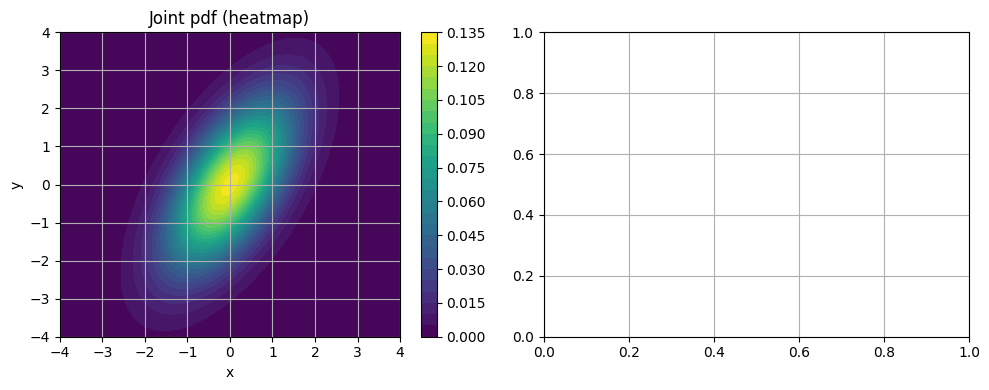

In [19]:
sx_, sy_, rho_ = 1.0, 1.5, 0.6
mean = np.array([0.0, 0.0])
cov = np.array([[sx_**2, rho_ * sx_ * sy_], [rho_ * sx_ * sy_, sy_**2]])
rv = multivariate_normal(mean, cov)

xg = np.linspace(-4, 4, 200) # [-4, -3.96, -3.92, ..., 3.92, 3.96, 4]
yg = np.linspace(-4, 4, 200) # [-4, -3.96, -3.92, ..., 3.92, 3.96, 4]
Xg, Yg = np.meshgrid(xg, yg) # Xg.shape = (200, 200), Yg.shape = (200, 200)
pos = np.dstack((Xg, Yg)) # pos.shape = (200, 200, 2)
Z = rv.pdf(pos) # Z.shape = (200, 200)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
cs = axes[0].contourf(Xg, Yg, Z, levels=30)
fig.colorbar(cs, ax=axes[0])
axes[0].set_title("Joint pdf (heatmap)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

plt.tight_layout()
plt.show()

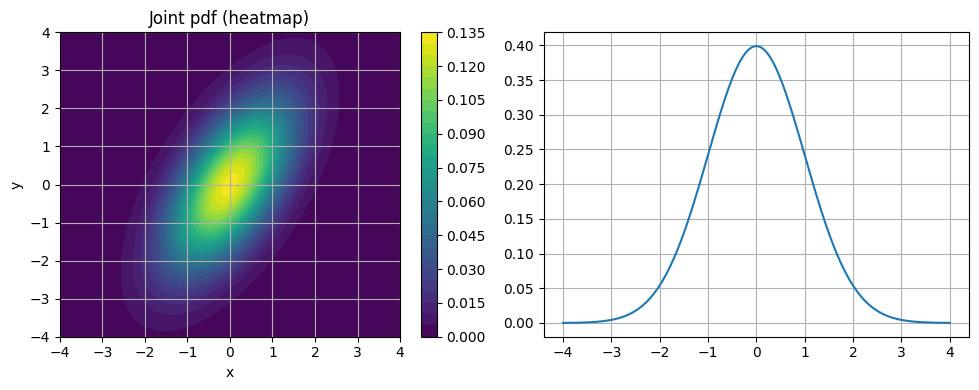

In [20]:
marg = (1 / np.sqrt(2 * np.pi * sx_**2)) * np.exp(-0.5 * xg**2 / sx_**2)
axes[1].plot(xg, marg, label=r"$f_X(x)$ analytic")
display(fig)

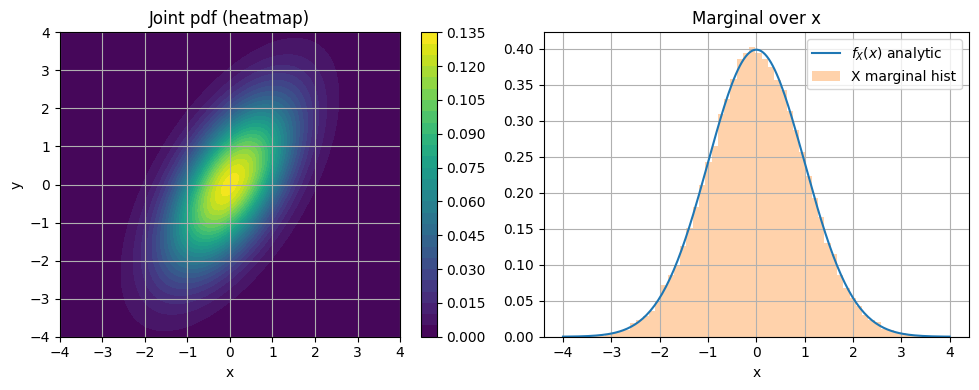

In [ ]:
samples = rv.rvs(size=50_000)
axes[1].hist(samples[:, 0], bins=60, density=True, alpha=0.35, label="X marginal hist")
# empirical marginalization - all the samples of $x$, discard $y$
axes[1].set_title("Marginal over x")
axes[1].set_xlabel("x")
axes[1].legend()

display(fig)


## Solution 3 — Two-component MoG and SymPy normalization

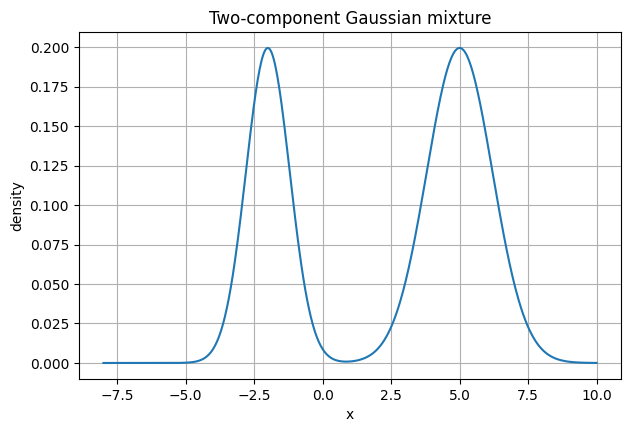

In [24]:
def mog_pdf(x: float, 
    weights: list[float], 
    mus: list[float], 
    sigmas: list[float]) -> float:
    p = 0
    for w, m, s in zip(weights, mus, sigmas):
        p += w * (1 / np.sqrt(2 * np.pi * s**2)) * np.exp(-0.5 * (x - m) ** 2 / s**2)
    return p

x = np.linspace(-8, 10, 500)
weights = [0.4, 0.6]
mus = [-2.0, 5.0]
sigmas = [0.8, 1.2]

plt.figure()
values = []
for i in range(len(x)):
    values.append(mog_pdf(x[i], weights, mus, sigmas))
values = np.array(values)
plt.plot(x, values) 
plt.title("Two-component Gaussian mixture")
plt.xlabel("x")
plt.ylabel("density")
plt.show()


In [26]:
# Empirical marginalization

pi = 0.4
n = 200_000
mus = [-2.0, 5.0]
sigmas = [0.8, 1.2]

rng = np.random.default_rng(0)
x_s = np.where(
    rng.binomial(1, pi, size=n),
    rng.normal(mus[0], sigmas[0], size=n),
    rng.normal(mus[1], sigmas[1], size=n),
)
mu_hat, var_hat = x_s.mean(), x_s.var(ddof=0)

print("MC mean:", mu_hat, "\n MC var:", var_hat)

MC mean: 2.210415175905622 
 MC var: 12.88165209690882


In [27]:
# Analytical marginalization

pi = 0.4
mus = [-2.0, 5.0]
sigmas = [0.8, 1.2]

mu_th = pi * mus[0] + (1 - pi) * mus[1]
ex2 = pi * (mus[0] ** 2 + sigmas[0] ** 2) + (1 - pi) * (mus[1] ** 2 + sigmas[1] ** 2)
var_th = ex2 - mu_th**2
print("Theoretical mean", mu_th, "\nTheoretical var", var_th)


Theoretical mean 2.2 
Theoretical var 12.880000000000003
